### **Predictive Analysis And Modeling**

***Introduction :-***

Predictive analysis uses historical data and machine learning to forecast outcomes. In HR, it helps predict employee performance, salary, and workforce trends.

The Indian Employee Data dataset includes age, gender, education, department, experience, salary, performance rating, projects completed, overtime hours, city, and state.



In [ ]:
#Importing Python Libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [125]:
#Loading Data set
from google.colab import files
uploaded=files.upload()

Saving Indian_Employee_Data.csv to Indian_Employee_Data (2).csv


In [ ]:
import pandas as pd
df=pd.read_csv("Indian_Employee_Data.csv")
print(df)

   Employee_ID            Name   Age  Gender   Department  \
0       EMP001    Rajesh Kumar  32.0    Male  Engineering   
1       EMP002    Priya Sharma  28.0  Female    Marketing   
2       EMP003      Amit Singh  35.0    Male      Finance   
3       EMP004     Sneha Patel  26.0  Female          NaN   
4       EMP005    Vikram Reddy  40.0    Male  Engineering   
5       EMP006      Kavya Nair  29.0  Female        Sales   
6       EMP007     Arjun Gupta  31.0    Male  Engineering   
7       EMP008     Meera Joshi  27.0  Female       Design   
8       EMP009   Rohit Agarwal  33.0    Male      Finance   
9       EMP010     Anita Verma  38.0  Female           HR   
10      EMP011     Suresh Iyer  42.0    Male  Engineering   
11      EMP012  Pooja Malhotra   NaN  Female    Marketing   
12      EMP013    Karan Chopra  30.0    Male        Sales   
13      EMP014       Divya Rao  34.0  Female  Engineering   
14      EMP015    Manoj Tiwari  36.0    Male   Operations   
15      EMP016     Ritu 

In [127]:
#Displays First 5 Rows
df.head()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32.0,Male,Engineering,Senior Developer,850000.0,8.0,Bangalore,Karnataka,B.Tech,4.2,03/15/2016,12.0,45.0
1,EMP002,Priya Sharma,28.0,Female,Marketing,Marketing Manager,720000.0,5.0,Mumbai,Maharashtra,MBA,4.5,01/20/2019,8.0,32.0
2,EMP003,Amit Singh,35.0,Male,Finance,Financial Analyst,650000.0,10.0,Delhi,Delhi,CA,3.8,07/10/2014,15.0,28.0
3,EMP004,Sneha Patel,26.0,Female,NaN,HR Executive,480000.0,3.0,Ahmedabad,Gujarat,MBA,4.1,05/12/2021,6.0,20.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,11/08/2009,25.0,55.0


In [128]:
#Displays Last 5 Rows
df.tail()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
44,EMP045,Neha Kapoor,28.0,Female,IT,Data Analyst,NaN,4.0,Bangalore,Karnataka,M.Sc,3.8,04/12/2020,6.0,29.0
45,EMP046,Amit Sharma,27.0,Male,IT,Junior Developer,650000.0,4.0,Delhi,NaN,B.Tech,4.5,08/20/2020,5.0,25.0
46,EMP047,Riya Gupta,32.0,Female,HR,HR Specialist,NaN,8.0,Mumbai,Maharashtra,MBA,NaN,11/03/2016,inf,42.0
47,EMP048,Rohit Bansal,36.0,Male,Finance,Senior Analyst,980000.0,12.0,Mumbai,Maharashtra,CA,4.9,03/20/2012,19.0,51.0
48,EMP049,Sneha Tiwari,25.0,Female,Sales,Sales Representative,inf,2.0,Kolkata,West Bengal,B.Com,3.6,05/14/2022,3.0,16.0


In [140]:
#displays Columns in dataset
df.columns

Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Position',
       'Salary', 'Experience_Years', 'City', 'State', 'Education',
       'Performance_Rating', 'Joining_Date', 'Projects_Completed',
       'Overtime_Hours'],
      dtype='object')

In [ ]:
#Gives Sample
df.sample(5)

In [129]:
#use to check size of Dataset
df.shape

(49, 15)

In [130]:
#Gives Infomation Of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         49 non-null     object 
 1   Name                49 non-null     object 
 2   Age                 47 non-null     float64
 3   Gender              49 non-null     object 
 4   Department          48 non-null     object 
 5   Position            48 non-null     object 
 6   Salary              44 non-null     float64
 7   Experience_Years    47 non-null     float64
 8   City                49 non-null     object 
 9   State               46 non-null     object 
 10  Education           49 non-null     object 
 11  Performance_Rating  45 non-null     float64
 12  Joining_Date        48 non-null     object 
 13  Projects_Completed  48 non-null     float64
 14  Overtime_Hours      48 non-null     float64
dtypes: float64(6), object(9)
memory usage: 5.9+ KB


In [131]:
#Datatype
df.dtypes

,0
Employee_ID,object
Name,object
Age,float64
Gender,object
Department,object
Position,object
Salary,float64
Experience_Years,float64
City,object
State,object


In [133]:
#Statstical Summary
df.describe()

,Age,Salary,Experience_Years,Performance_Rating,Projects_Completed,Overtime_Hours
count,47.000000,44.0,47.0,45.000000,48.00,48.0
mean,32.914894,inf,inf,4.295556,inf,inf
std,6.990148,NaN,NaN,0.401110,NaN,NaN
min,23.000000,-45000.0,2.0,3.500000,2.00,12.0
25%,28.000000,642500.0,4.0,4.000000,7.00,28.0
50%,31.000000,765000.0,7.0,4.300000,12.00,37.0
75%,36.000000,1062500.0,10.0,4.600000,18.25,46.5
max,55.000000,inf,inf,5.000000,inf,inf


In [ ]:
#Check Missing Values
df.isnull().sum()

,0
Employee_ID,0
Name,0
Age,2
Gender,0
Department,1
Position,1
Salary,5
Experience_Years,2
City,0
State,3


In [ ]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [134]:
#removes duplicates
df=df.drop_duplicates()

In [142]:
from sklearn.preprocessing import LabelEncoder

#Converts Categorical Columns
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
#Select Columns
df["Name"]
df["Department"]
df[["Name", "Department"]]

,Name,Department
0,Rajesh Kumar,Engineering
1,Priya Sharma,Marketing
2,Amit Singh,Finance
3,Sneha Patel,NaN
4,Vikram Reddy,Engineering
5,Kavya Nair,Sales
6,Arjun Gupta,Engineering
7,Meera Joshi,Design
8,Rohit Agarwal,Finance
9,Anita Verma,HR


In [ ]:
#Unique Values
df["Department"].unique()
df["Department"].nunique()

9

In [ ]:
#Filter Data
df[df["Age"] > 30]

df[df["Gender"] == "Female"]

df[df["Department"] == "IT"]

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
25,EMP026,Arjun Pandey,NaN,Male,IT,Software Engineer,750000.0,7.0,Jaipur,Rajasthan,B.Tech,4.4,06/15/2017,11.0,37.0
26,EMP027,Neha Kapoor,28.0,Female,IT,Data Analyst,NaN,4.0,Bangalore,Karnataka,M.Sc,3.8,04/12/2020,6.0,29.0
27,EMP028,Amit Sharma,27.0,Male,IT,Junior Developer,650000.0,4.0,Delhi,NaN,B.Tech,4.5,08/20/2020,5.0,25.0
30,EMP031,Priya Singh,29.0,Female,IT,QA Engineer,720000.0,6.0,Kolkata,West Bengal,B.Tech,4.2,09/14/2018,NaN,33.0
33,EMP034,Kavita Yadav,31.0,Female,IT,DevOps Engineer,inf,10.0,Pune,Maharashtra,B.Tech,4.0,12/07/2014,15.0,44.0
36,EMP037,Ramesh Patel,29.0,Male,IT,Backend Developer,720000.0,6.0,Kolkata,West Bengal,B.Tech,4.2,NaN,9.0,35.0
39,EMP040,Swati Joshi,29.0,Female,IT,Full Stack Developer,650000.0,5.0,Mumbai,Maharashtra,B.Tech,NaN,04/30/2019,8.0,31.0
43,EMP044,Arjun Pandey,31.0,Male,IT,Software Engineer,750000.0,7.0,Jaipur,Rajasthan,B.Tech,4.4,06/15/2017,11.0,37.0
44,EMP045,Neha Kapoor,28.0,Female,IT,Data Analyst,NaN,4.0,Bangalore,Karnataka,M.Sc,3.8,04/12/2020,6.0,29.0
45,EMP046,Amit Sharma,27.0,Male,IT,Junior Developer,650000.0,4.0,Delhi,NaN,B.Tech,4.5,08/20/2020,5.0,25.0


In [ ]:
#Sorting
df.sort_values("Age")
df.sort_values("Salary", ascending=False)

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
33,EMP034,Kavita Yadav,31.0,Female,IT,DevOps Engineer,inf,10.0,Pune,Maharashtra,B.Tech,4.0,12/07/2014,15.0,44.0
48,EMP049,Sneha Tiwari,25.0,Female,Sales,Sales Representative,inf,2.0,Kolkata,West Bengal,B.Com,3.6,05/14/2022,3.0,16.0
40,EMP041,Vinod Iyer,55.0,Male,Management,CEO,5000000.0,35.0,Chennai,Tamil Nadu,MBA,5.0,01/15/1989,inf,80.0
35,EMP036,Deepika Roy,48.0,Female,Management,Director,3000000.0,30.0,Bangalore,Karnataka,MBA,5.0,03/12/1994,50.0,72.0
32,EMP033,Alok Mehta,52.0,Male,Operations,VP Operations,2000000.0,28.0,Hyderabad,Telangana,MBA,5.0,05/18/1996,45.0,inf
10,EMP011,Suresh Iyer,42.0,Male,Engineering,Principal Engineer,1350000.0,18.0,Chennai,Tamil Nadu,M.Tech,4.8,01/25/2006,30.0,60.0
42,EMP043,Manish Khanna,40.0,Male,Operations,Operations Head,1250000.0,18.0,Hyderabad,Telangana,B.Tech,4.7,07/08/2006,32.0,62.0
29,EMP030,Rajesh Verma,45.0,Male,Finance,CFO,1200000.0,inf,Bangalore,Karnataka,CA,4.9,02/28/2005,28.0,65.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,11/08/2009,25.0,55.0
16,EMP017,Deepak Kumar,39.0,Male,Engineering,Software Architect,1150000.0,14.0,Hyderabad,Telangana,M.Tech,4.6,02/12/2010,inf,52.0


In [ ]:
#Group By
df.groupby("Department")["Salary"].mean()

df.groupby("Gender")["Salary"].mean()

,Salary
Gender,
Female,inf
Male,1053000.0


In [ ]:
#Highest Salary Employee
df.loc[df["Salary"].idxmax()]

,33
Employee_ID,EMP034
Name,Kavita Yadav
Age,31.0
Gender,Female
Department,IT
Position,DevOps Engineer
Salary,inf
Experience_Years,10.0
City,Pune
State,Maharashtra


In [ ]:
#Lowest Salary Employee
df.loc[df["Salary"].idxmin()]

,34
Employee_ID,EMP035
Name,Pankaj Mishra
Age,24.0
Gender,Male
Department,Marketing
Position,Marketing Associate
Salary,-45000.0
Experience_Years,2.0
City,Jaipur
State,Rajasthan


In [ ]:
#Count Employees by Department
df["Department"].value_counts()

,count
Department,
IT,10
Engineering,8
Finance,7
HR,6
Sales,5
Operations,4
Marketing,4
Design,2
Management,2


In [ ]:
#Correlation
df.corr(numeric_only=True)

,Age,Salary,Experience_Years,Performance_Rating,Projects_Completed,Overtime_Hours
Age,1.000000,0.826600,0.973331,0.737859,0.961485,0.934710
Salary,0.826600,1.000000,0.902974,0.654741,0.930494,0.767690
Experience_Years,0.973331,0.902974,1.000000,0.722293,0.994832,0.908405
Performance_Rating,0.737859,0.654741,0.722293,1.000000,0.712924,0.773757
Projects_Completed,0.961485,0.930494,0.994832,0.712924,1.000000,0.908197
Overtime_Hours,0.934710,0.767690,0.908405,0.773757,0.908197,1.000000


In [144]:
#Build prediction Model
X = df[['Age', 'Experience_Years', 'Performance_Rating', 'Projects_Completed', 'Overtime_Hours']]
y = df['Salary']

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values in X or y for this demonstration
combined = pd.concat([X, y], axis=1).dropna()
X = combined[X.columns]
y = combined[y.name]

#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Make Predictions
y_pred = model.predict(X_test)
print(y_pred)

[ 506010.86755389  653865.58934913 1585939.7449409   447094.87775754
  378991.52928129  499103.63116067]


In [ ]:
#Model Coefficients
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -1864292.0726588222
Slope: -3899.3300683495327


In [ ]:
#Evaluate Model
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 73760500425.04924
R2 Score: 0.03345902693489167


In [ ]:
#Predict New Value
# The model was trained on 5 features, so we need to provide 5 features for prediction.
# We will use the provided age and the mean of the other features from the training data.

new_data = {
    'Age': [30],
    'Experience_Years': [X_train['Experience_Years'].mean()],
    'Performance_Rating': [X_train['Performance_Rating'].mean()],
    'Projects_Completed': [X_train['Projects_Completed'].mean()],
    'Overtime_Hours': [X_train['Overtime_Hours'].mean()]
}

new_data_df = pd.DataFrame(new_data)

predicted_salary = model.predict(new_data_df)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 849621.1133464782


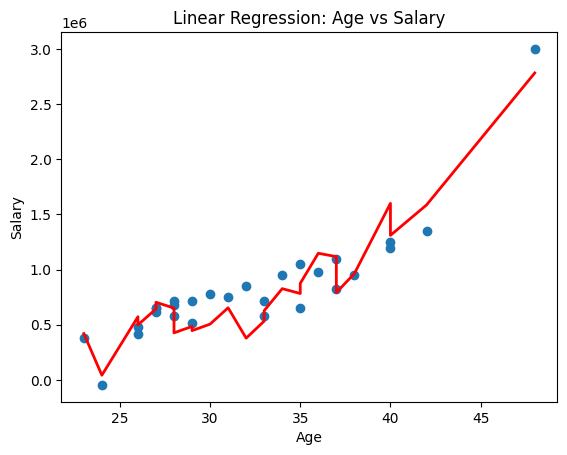

In [ ]:
#Visualization
import matplotlib.pyplot as plt

# Create a DataFrame for plotting, combining Age and predicted Salary
# This ensures we can sort the predicted values corresponding to Age for a smooth line
plot_data = pd.DataFrame({'Age': X['Age'], 'Predicted_Salary': model.predict(X)})
plot_data = plot_data.sort_values(by='Age')

plt.scatter(X['Age'], y) # Scatter plot of actual Age vs. actual Salary
plt.plot(plot_data['Age'], plot_data['Predicted_Salary'], color='red', linewidth=2) # Regression line based on predicted values
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Linear Regression: Age vs Salary")
plt.show()

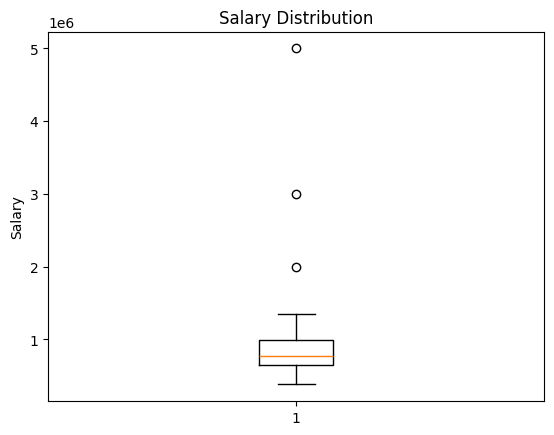

In [ ]:
#Boxplot of Salary Distribution
plt.boxplot(df_cleaned['Salary'])
plt.ylabel("Salary")
plt.title("Salary Distribution")
plt.show()

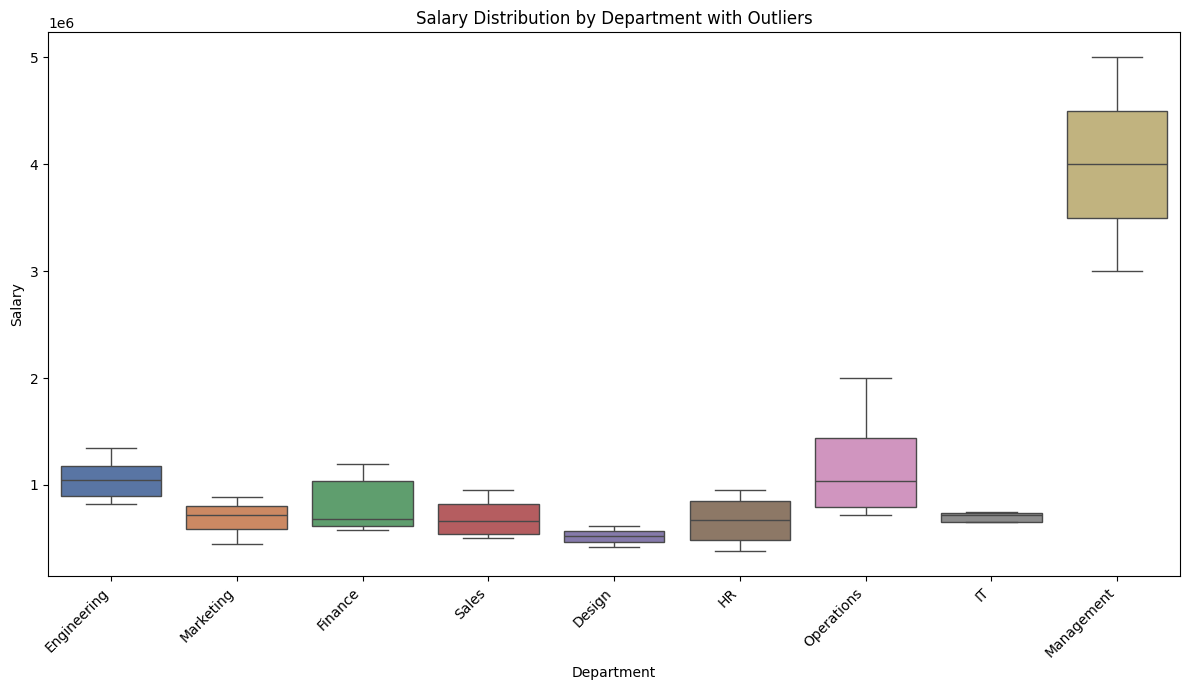

In [ ]:
#Boxplot
import seaborn as sns

# Create a cleaned DataFrame for plotting
df_cleaned = df.copy()
# Replace inf/-inf in 'Salary' with NaN and drop NaNs
df_cleaned['Salary'] = df_cleaned['Salary'].replace([np.inf, -np.inf], np.nan)
df_cleaned = df_cleaned.dropna(subset=['Salary', 'Department'])
# Filter out negative salaries, as they are likely data errors
df_cleaned = df_cleaned[df_cleaned['Salary'] >= 0]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Department', y='Salary', data=df_cleaned, palette='deep', hue='Department', legend=False)
plt.title('Salary Distribution by Department with Outliers')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

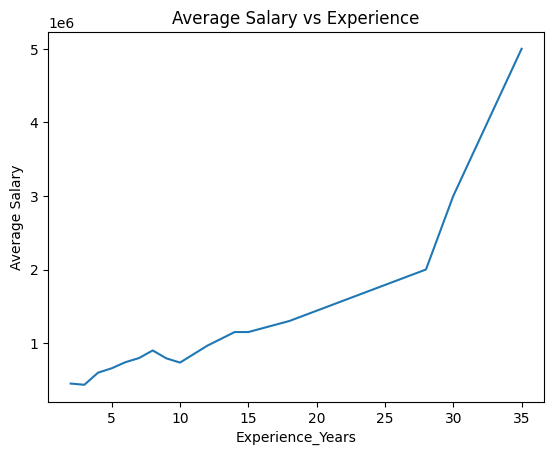

In [136]:
#Average Salary Vs Experience
salary_exp=df_cleaned.groupby('Experience_Years')['Salary'].mean()
plt.plot(salary_exp.index,salary_exp.values)
plt.xlabel("Experience_Years")
plt.ylabel("Average Salary")
plt.title("Average Salary vs Experience")
plt.show()

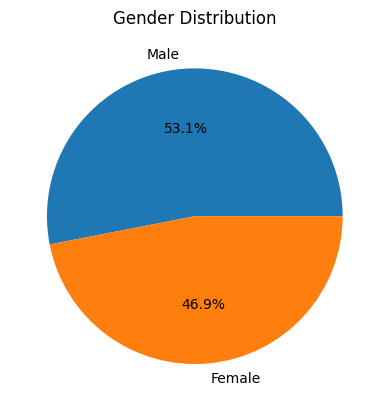

In [ ]:
#Pie Chart
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

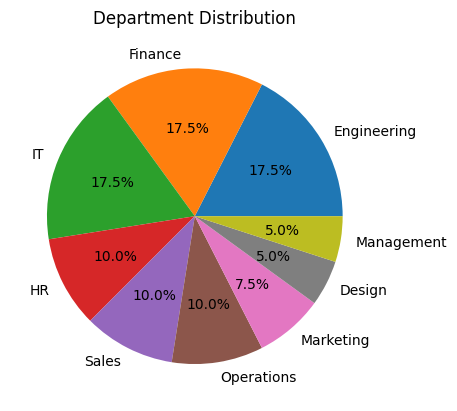

In [ ]:
#Pie chart of Department Distribution
department_count=df_cleaned['Department'].value_counts()
plt.pie(department_count.values,labels=department_count.index,autopct="%1.1f%%")
plt.title("Department Distribution")
plt.show()

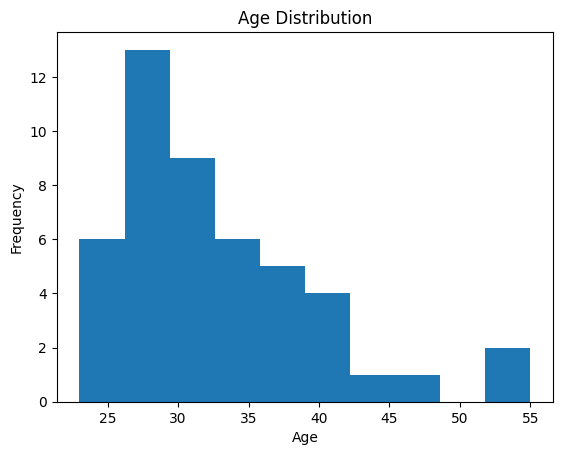

In [ ]:
#Histogram
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

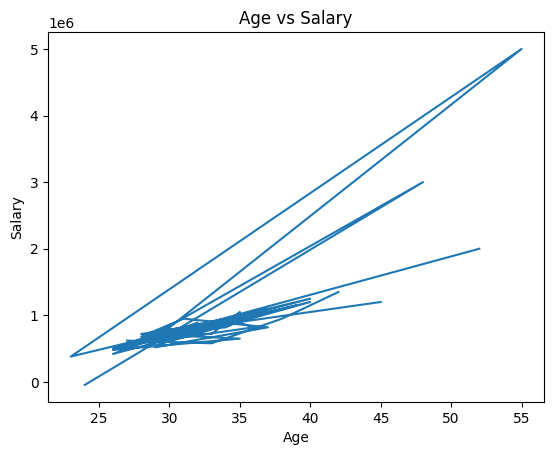

In [ ]:
#Line Graph
plt.plot(df["Age"], df["Salary"])
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

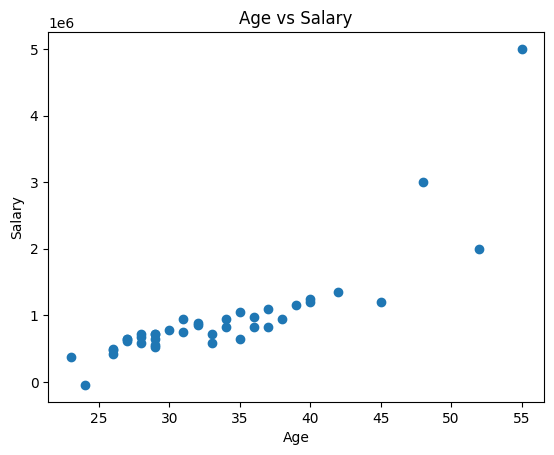

In [ ]:
#Scatter Plot (Very Important for Linear Regression)
plt.scatter(df["Age"], df["Salary"])
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

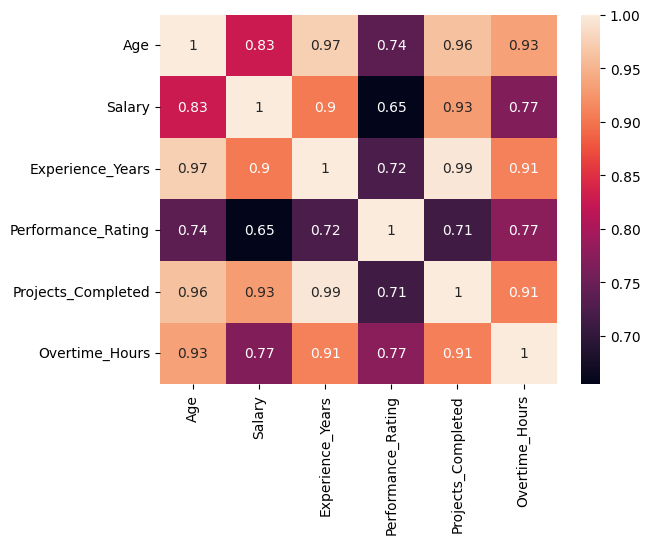

In [ ]:
#Correlation Heatmap
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
print("Value counts for 'promotion' (y):")
print(y.value_counts())
print("\nMinimum Performance_Rating in df:",df['Performance_Rating'].min())
print("Maximum Performance_Rating in df:",df['Performance_Rating'].max())
print("\nThis model requires at least two classes in the target variable.")

# The features DataFrame is named X (uppercase), not x. Correcting the name.
# Also, X_train, X_test, y_train, y_test were already defined in a previous cell.
# The problem is regression (predicting Salary), so LogisticRegression is not appropriate.
# x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# model=LogisticRegression()

Value counts for 'promotion' (y):
Salary
 720000.0     3
 650000.0     3
 950000.0     2
 580000.0     2
 850000.0     1
 480000.0     1
 620000.0     1
 1200000.0    1
 1350000.0    1
 780000.0     1
 420000.0     1
 520000.0     1
 820000.0     1
 680000.0     1
 1050000.0    1
-45000.0      1
 3000000.0    1
 1100000.0    1
 380000.0     1
 1250000.0    1
 750000.0     1
 980000.0     1
Name: count, dtype: int64

Minimum Performance_Rating in df: 3.5
Maximum Performance_Rating in df: 5.0

This model requires at least two classes in the target variable.


In [ ]:
eligible=df[df["Performance_Rating"]>=4.5]
print("===Eligible for promotion===")
print(eligible[["Employee_ID","Name","Performance_Rating"]])

===Eligible for promotion===
   Employee_ID           Name  Performance_Rating
1       EMP002   Priya Sharma                 4.5
4       EMP005   Vikram Reddy                 4.7
9       EMP010    Anita Verma                 4.6
10      EMP011    Suresh Iyer                 4.8
13      EMP014      Divya Rao                 4.5
16      EMP017   Deepak Kumar                 4.6
21      EMP022   Preeti Singh                 4.5
24      EMP025   Vishal Gupta                 4.7
27      EMP028    Amit Sharma                 4.5
29      EMP030   Rajesh Verma                 4.9
32      EMP033     Alok Mehta                 5.0
35      EMP036    Deepika Roy                 5.0
38      EMP039   Sameer Desai                 4.8
40      EMP041     Vinod Iyer                 5.0
42      EMP043  Manish Khanna                 4.7
45      EMP046    Amit Sharma                 4.5
47      EMP048   Rohit Bansal                 4.9


In [ ]:
eligible_for_increment = df[df['Performance_Rating'] >= 4.0]
not_eligible_for_increment = df[df['Performance_Rating'] < 4.0]

print("=== Employees Eligible for Increment ===")
print(eligible_for_increment[['Employee_ID', 'Name', 'Performance_Rating','Projects_Completed']])

print("\n=== Employees Not Eligible for Increment ===")
print(not_eligible_for_increment[['Employee_ID', 'Name', 'Performance_Rating','Projects_Completed']])

=== Employees Eligible for Increment ===
   Employee_ID            Name  Performance_Rating  Projects_Completed
0       EMP001    Rajesh Kumar                 4.2                12.0
1       EMP002    Priya Sharma                 4.5                 8.0
3       EMP004     Sneha Patel                 4.1                 6.0
4       EMP005    Vikram Reddy                 4.7                25.0
6       EMP007     Arjun Gupta                 4.3                11.0
7       EMP008     Meera Joshi                 4.4                 7.0
9       EMP010     Anita Verma                 4.6                18.0
10      EMP011     Suresh Iyer                 4.8                30.0
11      EMP012  Pooja Malhotra                 4.0                 4.0
12      EMP013    Karan Chopra                 4.2                10.0
13      EMP014       Divya Rao                 4.5                14.0
14      EMP015    Manoj Tiwari                 4.1                16.0
16      EMP017    Deepak Kumar      

In [ ]:
def calculate_increment_percentage(row):
  if row['Performance_Rating'] >= 4.5 and row['Projects_Completed'] >= 15:
    return 0.15
  elif row['Performance_Rating'] >= 4.0 and row['Projects_Completed'] >= 10:
    return 0.10
  else:
    return 0.05

eligible_for_increment_copy = eligible_for_increment.copy() # Create an explicit copy to avoid SettingWithCopyWarning
eligible_for_increment_copy['Increment_Percentage'] = eligible_for_increment_copy.apply(calculate_increment_percentage, axis=1)
eligible_for_increment_copy['New_Salary'] = eligible_for_increment_copy['Salary'] * (1 + eligible_for_increment_copy['Increment_Percentage'])
print("===Increment Salary===")
print(eligible_for_increment_copy[['Employee_ID','Name','Increment_Percentage','New_Salary']])

===Increment Salary===
   Employee_ID            Name  Increment_Percentage  New_Salary
0       EMP001    Rajesh Kumar                  0.10    935000.0
1       EMP002    Priya Sharma                  0.05    756000.0
3       EMP004     Sneha Patel                  0.05    504000.0
4       EMP005    Vikram Reddy                  0.15   1380000.0
6       EMP007     Arjun Gupta                  0.10         NaN
7       EMP008     Meera Joshi                  0.05    651000.0
9       EMP010     Anita Verma                  0.15   1092500.0
10      EMP011     Suresh Iyer                  0.15   1552500.0
11      EMP012  Pooja Malhotra                  0.05    472500.0
12      EMP013    Karan Chopra                  0.10    858000.0
13      EMP014       Divya Rao                  0.10   1045000.0
14      EMP015    Manoj Tiwari                  0.10    902000.0
16      EMP017    Deepak Kumar                  0.15   1322500.0
17      EMP018    Sonia Kapoor                  0.05    441000.0
19

In [ ]:
if not eligible_for_increment.empty:
    print("\n=== Employees Eligible for Increment ===")
    print(eligible_for_increment[['Employee_ID', 'Name', 'Performance_Rating','Projects_Completed']])
elif not not_eligible_for_increment.empty:
    print("\n=== Employees Not Eligible for Increment ===")
    print(not_eligible_for_increment[['Employee_ID', 'Name', 'Performance_Rating','Projects_Completed']])
else:
    print("No eligible or not eligible employees found.")


=== Employees Eligible for Increment ===
   Employee_ID            Name  Performance_Rating  Projects_Completed
0       EMP001    Rajesh Kumar                 4.2                12.0
1       EMP002    Priya Sharma                 4.5                 8.0
3       EMP004     Sneha Patel                 4.1                 6.0
4       EMP005    Vikram Reddy                 4.7                25.0
6       EMP007     Arjun Gupta                 4.3                11.0
7       EMP008     Meera Joshi                 4.4                 7.0
9       EMP010     Anita Verma                 4.6                18.0
10      EMP011     Suresh Iyer                 4.8                30.0
11      EMP012  Pooja Malhotra                 4.0                 4.0
12      EMP013    Karan Chopra                 4.2                10.0
13      EMP014       Divya Rao                 4.5                14.0
14      EMP015    Manoj Tiwari                 4.1                16.0
16      EMP017    Deepak Kumar     

In [ ]:
def performance_class(rating):
  if rating<3.5:
    return 0
  elif 3.5<= rating <4.2:
    return 1
  else:
    return 2
df_temp = pd.read_csv('Indian_Employee_Data.csv')
df_temp['Performance_Class']=df_temp['Performance_Rating'].apply(performance_class)
top_5_employees_display=df_temp.sort_values(by='Performance_Class',ascending=False).head(5)
print("Top 5 Employees by Performance Class:")
display(top_5_employees_display[['Employee_ID','Name','Performance_Class']])

Top 5 Employees by Performance Class:


,Employee_ID,Name,Performance_Class
0,EMP001,Rajesh Kumar,2
1,EMP002,Priya Sharma,2
4,EMP005,Vikram Reddy,2
7,EMP008,Meera Joshi,2
6,EMP007,Arjun Gupta,2


In [ ]:
#Training Model
iris=load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
y=pd.Series(iris.target, name='species')
model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X,y)
print("Modeltrained successfully")

Modeltrained successfully


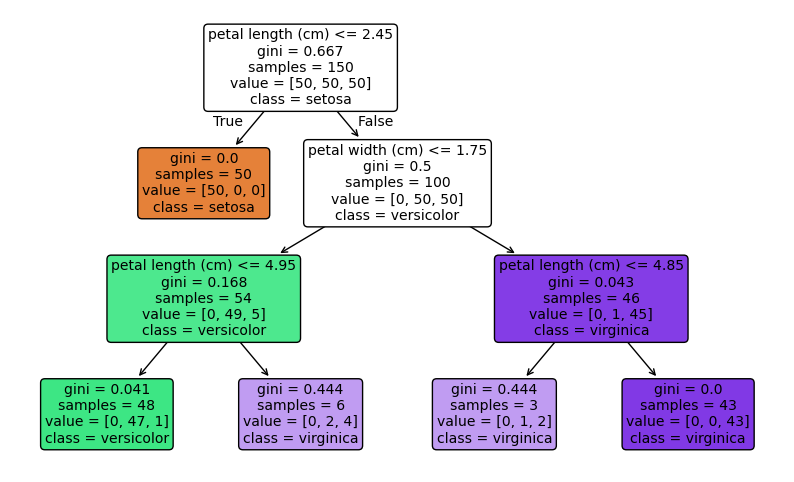

In [ ]:
#Ploting Tree
plt.figure(figsize=(10,6))
plot_tree(model,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,rounded=True)
plt.show()

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
prediction = tree.predict(X_test)
print("\n===Decision Tree===")
print("Accuracy:", accuracy_score(y_test, prediction))
print("Precision:", precision_score(y_test, prediction, average='weighted'))


===Decision Tree===
Accuracy: 0.8333333333333334
Precision: 0.8666666666666667


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

X=df[["Age","Salary","Experience_Years","Projects_Completed","Overtime_Hours"]]
bins=[0,3.7,4.3,5.0]
labels=['Low','Medium','High']
y=pd.cut(df['Performance_Rating'],bins=bins, labels=labels,include_lowest=True)

# Replace infinite values with NaN in X
X = X.replace([np.inf, -np.inf], np.nan)

# Combine X and y, then drop rows with any NaN values to ensure alignment
combined_data = pd.concat([X, y], axis=1)
combined_data_cleaned = combined_data.dropna()

# Separate X and y again from the cleaned data
X = combined_data_cleaned.drop(columns=['Performance_Rating'])
y = combined_data_cleaned['Performance_Rating']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.8333333333333334
Confusion Matrix:
 [[3 0]
 [1 2]]
Classification Report:
               precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
      Medium       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



In [ ]:
#Save Updated CSV
df.to_csv("Updated_Employee_Data.csv", index=False)

## **Conclusion :-**

***Predictive analysis helps analyze employee data and forecast outcomes. Machine learning on the Indian Employee dataset can improve salary and performance prediction and support better HR decisions.***